# 🚚 Shipment Delay Risk — ML Pipeline (Teaching / Demo Layer)

This notebook is the **narrative layer** of the *Logistics Delay-Risk Prediction &
Carbon Cost Dashboard* project. Its purpose is not to ship a production model; it is
to answer *"how does the model actually arrive at this decision?"* step by step, in a
way you can see.

Production scoring lives in `src/ml_delay_risk_pipeline.py`, and **only that script**
produces `Fact_Shipments_with_ML.csv`, the file that feeds the Power BI report. This
notebook never touches it (see Section 7).

---

## ⚠️ Methodological Warning — Do Not Interpret the Results Before Reading This

**The data used in this notebook is synthetic, and the data-generating process (DGP)
was written by us.** That directly changes how the results should be read:

| This notebook **does** demonstrate | This notebook does **not** demonstrate |
|---|---|
| That the pipeline is methodologically sound (encoding, splitting, no leakage) | That the model would perform like this on real shipment data |
| That a Random Forest can extract signal from a noisy stochastic process | That the feature-importance ranking is a genuine discovery |
| How a risk score is carried through to the BI layer | The commercial value or ROI of the model |

**A special warning about feature importance:** when a variable comes out "important"
on synthetic data, it is because *we* weighted it that way in the generator. The
ranking in the chart is therefore not a *finding* — it is a **readback of our own
assumptions**. Read the chart as a **sanity check** ("has the model learned to look at
the right thing?"), not as a business insight ("vendor rating is the biggest cause of
delay").

### What was fixed in this version

An earlier version of this notebook had a **circular target variable**: `Risk_Level`
was produced by a deterministic formula (`traffic*35 + weather*40 + vendor_rating*15
+ ...`), and then **exactly the same variables** were fed to the model as features.
The model was not learning a hidden pattern; it was algebraically inverting a formula
we had written ourselves. The 86% accuracy reported back then was not a generalisation
success but a formula-solving success — and reporting accuracy on a problem whose
irreducible uncertainty (Bayes error) is near zero is meaningless.

**The fix:** the target is now derived from an **observed outcome** rather than a
deterministic rule: `is_delayed = (Actual_Delay_Days > 0)`. `Actual_Delay_Days` is
produced by a two-stage stochastic process (see Section 1), so two shipments with the
same feature vector can end differently. Genuine uncertainty exists, and the model has
to **estimate a probability** instead of solving an equation.

`Risk_Level`, meanwhile, is no longer an **input** to the model but an **output**: it
is derived by binning the `predict_proba` result (Section 6) — exactly the same
approach as `src/ml_delay_risk_pipeline.py`.

<a id="limitations"></a>

### The full list of limitations

Everything the results do not support, in one place. The sections below refer back
here rather than repeating these points.

1. **The data is synthetic.** None of the numbers in this notebook is a prediction of
   real-world performance. On real data the biggest difficulty would probably not be
   modelling at all, but the fact that `Actual_Delay_Days` is not recorded
   consistently.

2. **The cost ratio (4:1) is an assumption.** The risk thresholds are derived from it,
   but the ratio itself has not been validated against real contractual penalties. It
   is isolated in the code as a single constant (`COST_FN_OVER_FP`) so it is easy to
   change.

3. **Calibration is weakest in the tail.** Overall ECE is ~0.02, but the top bucket
   (p > 0.8) contains few observations, so reliability there is lower. For the highest
   risk shipments, do not trust "85% likely to be late" as much as a mid-range figure.

4. **The warm-up period was not scored walk-forward.** The first ~17% of shipments have
   no "prior data", so they were filled with vendor-grouped out-of-fold scores. Those
   rows carry slightly optimistic scores.

5. **One year of data, one seasonal cycle.** Seasonality can be modelled, but
   year-over-year change (was this winter harsher than the last?) cannot be measured.
   Vendor quality is also **constant** over time — in reality vendor performance
   degrades or improves (concept drift), and there is nothing like that in this data.

6. **There is ±0.05 variation across chronological CV folds.** This comes from
   seasonality: AUC is high in winter folds (bad weather creates discriminating power)
   and low in summer folds. Do not mistake a single period's number for overall
   performance.

## Section 0 — Libraries

`LabelEncoder` was deliberately **removed**; the reasoning is in Section 3. We use
`ColumnTransformer` + `Pipeline` + `OneHotEncoder` instead, which is the same approach
as `src/ml_delay_risk_pipeline.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    cross_val_predict, StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit,
)
from copy import deepcopy
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score,
    brier_score_loss,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("✅ Libraries loaded.")
print(f"   pandas {pd.__version__} | seaborn {sns.__version__}")

✅ Libraries loaded.
   pandas 3.0.5 | seaborn 0.13.2


## Section 1 — Data Generation (schema-compatible with `src/`)

For portfolio purposes the notebook must be able to **run standalone**, so it
generates its own data — but with two critical differences from the earlier version:

**1. Schema compatibility.** The previous version produced a schema that clashed with
the `src/` layer: `Vendor_ID` was `VND-101` (src: `VEND-001`), `Route_ID` was a free
label that connected to no dimension table, `Vehicle_Type` was in Turkish (`Dizel
Tır`) while src used English (`Diesel Truck`), and there were 1,000 rows (src: 1,500).
We now speak **the same alphabet as src**: `VEND-0NN`, `RT-000NN` (derived from real
route combinations using the `etl_star_schema.py` logic), English vehicle types, 1,500
rows.

**1b. Time and seasonality.** Every shipment is assigned a `Shipment_Date` within the
last 12 months (volume rises in the year-end holiday season), and **weather is now
month-dependent**: on a Northern-Hemisphere cycle the probability of Snow/Storm rises
between November and February, while Normal dominates from June to August (the
probability of Snow in July is zero).

Design rule: **seasonality only determines which weather appears more often in which
month.** The effect of weather on delay, and its interaction with the vendor, do not
change at all. The chain is: `month → weather distribution → (weather × vendor) →
delay`. No new signal is added; the existing signal is given a temporal order. The
monthly distributions were chosen so that the **annual marginal** weather distribution
stays close to the old fixed values; the cell below verifies this.

**2. Delay is produced as a two-stage stochastic *outcome*** (a zero-inflated / hurdle
structure), with exactly the same coefficients as `src/generate_logistics_data.py`:

- **Stage 1 — will it be late?** Weather, traffic, vendor rating and distance form a
  *logit*; `sigmoid` turns it into a probability; a **Bernoulli draw** is made.
- **Stage 2 — by how many days?** A Poisson truncated to `1..5`, for late shipments only.

Two shipments with the same feature vector can end differently — the model is no
longer solving an equation, it is **estimating a probability**.

There is also a **weather × vendor interaction**: in an additive model, bad weather
pushes almost everyone over the threshold and the importance of vendor quality is
erased (a ceiling effect). Because the interaction term is centred on the mean rating,
increasing the multiplier widens the **spread** rather than shifting the mean: a good
vendor is hit less by a storm and a poor one more — while the marginal effect of
weather is largely preserved.

> **Note:** in an earlier revision, delay was produced from an additive score, and
> because every component was positive, **91%** of shipments were late. Under
> Storm/Snow/High the rate approached 100%, so those variables lost all discriminating
> power. Downstream, `High Risk Rate %` in Power BI came out at 84.3% — an early
> warning panel where 84% of shipments glow red warns of nothing.

✅ Generated a dataset of 1500 rows (1346 unique routes).
   Date range: 2025-08-01 .. 2026-07-31

--- Delay logic check: mean delay by weather ---
Weather_Condition
Storm     0.98
Snow      0.79
Rain      0.40
Normal    0.21
Name: Actual_Delay_Days, dtype: float64

--- Annual marginal weather distribution (vs the old fixed values) ---
        New (seasonal)  Old (fixed)
Normal           0.579          0.6
Rain             0.207          0.2
Storm            0.085          0.1
Snow             0.129          0.1

--- Monthly weather distribution (%) and realised delay rate ---
Weather_Condition  Normal  Rain  Storm  Snow  Shipments  Delay_%
Month                                                           
1                    26.8  20.6   17.5  35.1         97     28.9
2                    25.9  12.0   14.8  47.2        108     33.3
3                    46.4  32.1    9.8  11.6        112     20.5
4                    68.5  23.4    4.8   3.2        124     21.8
5                    64.2  

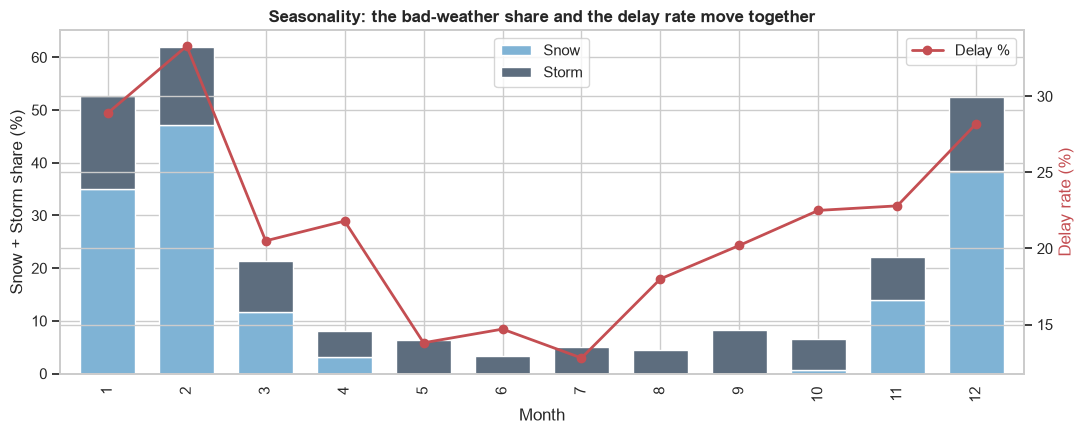

,Shipment_ID,Shipment_Date,Vendor_ID,Vendor_Rating,Origin,Destination,Distance_km,Weight_tons,Weather_Condition,Traffic_Density,Vehicle_Type,Actual_Delay_Days,CO2_Emission_kg,Route_ID
0,SHP-00001,2025-08-01,VEND-019,4.5,Denizli,Antalya,801.1,15.00,Normal,Medium,Hybrid Van,0,1028.03,RT-00294
1,SHP-00002,2025-08-01,VEND-005,2.1,Istanbul,Van,796.2,24.79,Normal,Low,Electric Semi,0,675.33,RT-00685
2,SHP-00003,2025-08-01,VEND-010,3.2,Ankara,Antalya,945.1,6.79,Normal,Low,Hybrid Van,1,501.99,RT-00076
3,SHP-00004,2025-08-01,VEND-012,4.6,Eskisehir,Mersin,527.6,7.29,Normal,Low,Electric Semi,0,136.21,RT-00537
4,SHP-00005,2025-08-02,VEND-013,3.7,Trabzon,Gaziantep,364.5,3.22,Normal,Medium,Electric Semi,0,45.00,RT-01262


In [2]:
rng = np.random.default_rng(RANDOM_STATE)
N_ROWS = 1500

CITIES = [
    "Istanbul", "Ankara", "Izmir", "Bursa", "Antalya", "Gaziantep",
    "Konya", "Adana", "Mersin", "Kayseri", "Samsun", "Kocaeli",
    "Trabzon", "Denizli", "Eskisehir", "Sakarya", "Diyarbakir",
    "Malatya", "Erzurum", "Van",
]

# The SAME ID format as src/generate_logistics_data.py: VEND-001 ... VEND-025
VENDOR_IDS = [f"VEND-{i:03d}" for i in range(1, 26)]

# Each vendor has a fixed quality profile; it fluctuates slightly per shipment.
vendor_base_rating = {vid: round(rng.uniform(1.5, 5.0), 1) for vid in VENDOR_IDS}

WEATHER = ["Normal", "Rain", "Storm", "Snow"]
WEATHER_P = [0.60, 0.20, 0.10, 0.10]
TRAFFIC = ["Low", "Medium", "High"]
TRAFFIC_P = [0.35, 0.40, 0.25]
# The same language as src: English vehicle types
VEHICLES = ["Diesel Truck", "Electric Semi", "Hybrid Van"]
VEHICLE_P = [0.55, 0.20, 0.25]

shipment_ids = [f"SHP-{i:05d}" for i in range(1, N_ROWS + 1)]
vendor_ids = rng.choice(VENDOR_IDS, size=N_ROWS)
vendor_ratings = np.array([
    np.clip(vendor_base_rating[v] + rng.normal(0, 0.15), 1.0, 5.0) for v in vendor_ids
]).round(1)

origins = rng.choice(CITIES, size=N_ROWS)
destinations = np.array([rng.choice([c for c in CITIES if c != o]) for o in origins])

distance_km = rng.uniform(50, 1200, size=N_ROWS).round(1)
weight_tons = rng.uniform(1, 25, size=N_ROWS).round(2)
# --- Shipment_Date + SEASONAL weather (the same tables as src) --------------
# Weather is no longer drawn from a fixed year-round distribution but PER MONTH.
# Chain: month -> weather distribution -> (weather x vendor) -> delay.
# The effect of weather on delay and its vendor interaction do NOT change.
#                       Normal  Rain  Storm  Snow
MONTHLY_WEATHER_PROBS = {
    1:  [0.30, 0.15, 0.17, 0.38],   # January   - peak winter
    2:  [0.32, 0.15, 0.17, 0.36],   # February
    3:  [0.50, 0.25, 0.12, 0.13],   # March     - transition
    4:  [0.62, 0.28, 0.08, 0.02],   # April     - spring rains
    5:  [0.70, 0.25, 0.05, 0.00],   # May
    6:  [0.82, 0.14, 0.04, 0.00],   # June
    7:  [0.88, 0.09, 0.03, 0.00],   # July      - clearest month of the year
    8:  [0.87, 0.10, 0.03, 0.00],   # August
    9:  [0.75, 0.19, 0.06, 0.00],   # September
    10: [0.62, 0.28, 0.09, 0.01],   # October   - autumn rains
    11: [0.45, 0.27, 0.14, 0.14],   # November  - first snow
    12: [0.33, 0.16, 0.16, 0.35],   # December
}
MONTHLY_VOLUME_WEIGHTS = {1: .85, 2: .80, 3: .90, 4: .95, 5: 1.0, 6: 1.0,
                          7: .95, 8: .90, 9: 1.05, 10: 1.10, 11: 1.25, 12: 1.35}

END = pd.Timestamp("2026-07-31")
all_days = pd.date_range(END - pd.DateOffset(months=12) + pd.Timedelta(days=1), END, freq="D")
day_w = np.array([MONTHLY_VOLUME_WEIGHTS[d.month] for d in all_days], dtype=float)
day_w /= day_w.sum()
shipment_dates = pd.DatetimeIndex(rng.choice(all_days, size=N_ROWS, p=day_w)).sort_values()
months = shipment_dates.month.to_numpy()

weather = np.empty(N_ROWS, dtype=object)
for mth, probs in MONTHLY_WEATHER_PROBS.items():
    msk = months == mth
    if msk.any():
        weather[msk] = rng.choice(WEATHER, size=int(msk.sum()), p=probs)
weather = weather.astype(str)

traffic = rng.choice(TRAFFIC, size=N_ROWS, p=TRAFFIC_P)
vehicle = rng.choice(VEHICLES, size=N_ROWS, p=VEHICLE_P)

# --- Actual_Delay_Days: two-stage (zero-inflated / hurdle) process ---------
# The SAME logic and the SAME coefficients as src/generate_logistics_data.py.
# Stage 1: will it be late?  Stage 2: how many days, for the late ones?
MAX_DELAY_DAYS, TARGET_DELAY_RATE = 5, 0.22

w_logit = {"Normal": 0.00, "Rain": 0.60, "Storm": 2.00, "Snow": 1.40}
t_logit = {"Low": 0.00, "Medium": 0.50, "High": 1.20}
# Weather x Vendor interaction: bad weather hits everyone, but hits a quality
# vendor less. Because the term is centred on VENDOR_PIVOT, the multiplier widens
# the spread rather than shifting the mean -> the marginal effect of weather is
# largely preserved.
w_amp = {"Normal": 0.00, "Rain": 0.20, "Storm": 0.75, "Snow": 0.50}
VENDOR_PIVOT, VENDOR_SLOPE = 3.25, 0.80

logit_wo_ic = (
    np.array([w_logit[w] for w in weather])
    + np.array([t_logit[t] for t in traffic])
    + (VENDOR_PIVOT - vendor_ratings) * VENDOR_SLOPE
      * np.array([1.0 + w_amp[w] for w in weather])
    + ((distance_km - 625.0) / 1200.0) * 0.50
)

# We derive the base rate rather than writing it as a magic constant.
lo, hi = -8.0, 4.0
for _ in range(90):
    mid = (lo + hi) / 2
    if (1 / (1 + np.exp(-(logit_wo_ic + mid)))).mean() < TARGET_DELAY_RATE:
        lo = mid
    else:
        hi = mid
INTERCEPT = (lo + hi) / 2

delay_probability = 1 / (1 + np.exp(-(logit_wo_ic + INTERCEPT)))
is_delayed_draw = rng.random(N_ROWS) < delay_probability

# Severity: a PROPERLY truncated Poisson over 1..5. Writing np.clip(1+Poisson(...))
# piles the tail up at 5 and breaks the monotonicity of the distribution.
lam = (0.30
       + np.array([{"Normal":0.0,"Rain":0.25,"Storm":1.10,"Snow":0.75}[w] for w in weather])
       + np.array([{"Low":0.0,"Medium":0.15,"High":0.45}[t] for t in traffic])
       + (VENDOR_PIVOT - vendor_ratings) * 0.18).clip(0.05, None)

k = np.arange(MAX_DELAY_DAYS)
log_fact = np.cumsum(np.concatenate(([0.0], np.log(np.arange(1, MAX_DELAY_DAYS)))))
pmf = np.exp(-lam[:, None] + k[None, :] * np.log(lam[:, None]) - log_fact[None, :])
pmf /= pmf.sum(axis=1, keepdims=True)
days = 1 + (rng.random(N_ROWS)[:, None] > pmf.cumsum(axis=1)).sum(axis=1)

actual_delay_days = np.where(is_delayed_draw, days, 0).astype(int)

# --- CO2_Emission_kg: for schema compatibility with the BI carbon measures ---
EMISSION_FACTOR = {"Diesel Truck": 0.13, "Electric Semi": 0.035, "Hybrid Van": 0.08}
BASE_EMISSION = {"Diesel Truck": 8.0, "Electric Semi": 1.5, "Hybrid Van": 4.0}
w_co2 = {"Normal": 1.00, "Rain": 1.03, "Storm": 1.08, "Snow": 1.06}
t_co2 = {"Low": 1.00, "Medium": 1.04, "High": 1.10}

co2 = (
    (distance_km * weight_tons * np.array([EMISSION_FACTOR[v] for v in vehicle])
     + np.array([BASE_EMISSION[v] for v in vehicle]))
    * np.array([w_co2[w] for w in weather])
    * np.array([t_co2[t] for t in traffic])
    * rng.normal(1.0, 0.03, size=N_ROWS)
)
co2_emission_kg = np.clip(co2, 0.5, None).round(2)

df = pd.DataFrame({
    "Shipment_ID": shipment_ids,
    "Shipment_Date": shipment_dates,
    "Vendor_ID": vendor_ids,
    "Vendor_Rating": vendor_ratings,
    "Origin": origins,
    "Destination": destinations,
    "Distance_km": distance_km,
    "Weight_tons": weight_tons,
    "Weather_Condition": weather,
    "Traffic_Density": traffic,
    "Vehicle_Type": vehicle,
    "Actual_Delay_Days": actual_delay_days,
    "CO2_Emission_kg": co2_emission_kg,
})

# Route_ID: the same logic as etl_star_schema.py - de-duplicate the unique route
# combinations and assign a surrogate key, so the FK relationship is meaningful.
route_cols = ["Origin", "Destination", "Vehicle_Type", "Weather_Condition", "Traffic_Density"]
dim_route = df[route_cols].drop_duplicates().sort_values(route_cols).reset_index(drop=True)
dim_route.insert(0, "Route_ID", [f"RT-{i:05d}" for i in range(1, len(dim_route) + 1)])
df = df.merge(dim_route, on=route_cols, how="left")

assert len(df) == N_ROWS, "The route join changed the row count!"
assert df["Route_ID"].notna().all(), "There is an unmatched Route_ID!"

print(f"✅ Generated a dataset of {len(df)} rows ({df['Route_ID'].nunique()} unique routes).")
print(f"   Date range: {df.Shipment_Date.min():%Y-%m-%d} .. {df.Shipment_Date.max():%Y-%m-%d}")

print("\n--- Delay logic check: mean delay by weather ---")
print(df.groupby("Weather_Condition")["Actual_Delay_Days"].mean().round(2).sort_values(ascending=False))

# SEASONALITY CHECK: the monthly distributions now differ, but the annual MARGINAL
# distribution must stay close to the old fixed values - otherwise the claim that
# "we only added a temporal order" collapses and the overall delay rate shifts too.
print("\n--- Annual marginal weather distribution (vs the old fixed values) ---")
print(pd.DataFrame({
    "New (seasonal)": df.Weather_Condition.value_counts(normalize=True).reindex(WEATHER).round(3),
    "Old (fixed)": pd.Series(WEATHER_P, index=WEATHER),
}).to_string())

_m = df.assign(Month=df.Shipment_Date.dt.month)
_p = (_m.pivot_table(index="Month", columns="Weather_Condition", values="Shipment_ID",
                     aggfunc="count", observed=True).reindex(columns=WEATHER).fillna(0))
_p = (_p.div(_p.sum(axis=1), axis=0) * 100).round(1)
_p["Shipments"] = _m.groupby("Month").size()
_p["Delay_%"] = _m.groupby("Month")["Actual_Delay_Days"].apply(lambda s: round((s > 0).mean()*100, 1))
print("\n--- Monthly weather distribution (%) and realised delay rate ---")
print(_p.to_string())

fig, ax1 = plt.subplots(figsize=(11, 4.5))
_p[["Snow", "Storm"]].plot(kind="bar", stacked=True, ax=ax1,
                           color=["#7fb3d5", "#5d6d7e"], width=.7)
ax1.set_ylabel("Snow + Storm share (%)"); ax1.set_xlabel("Month")
ax2 = ax1.twinx()
ax2.plot(range(len(_p)), _p["Delay_%"], "o-", color="#c44e52", lw=2, label="Delay %")
ax2.set_ylabel("Delay rate (%)", color="#c44e52")
ax1.set_title("Seasonality: the bad-weather share and the delay rate move together",
              fontweight="bold")
ax1.legend(loc="upper center"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

df.head()

## Section 2 — Target Variable: `is_delayed`

We derive the target from an **observed outcome**:

$$\text{is\_delayed} = \mathbb{1}[\text{Actual\_Delay\_Days} > 0]$$

Why a binary target instead of the 3-class `Risk_Level`?

1. **To break the circularity.** Making `Risk_Level` the target directly would mean
   reproducing a label whose thresholds we set ourselves. `Actual_Delay_Days`, by
   contrast, is what actually *happened to* the shipment.
2. **To obtain calibrated probabilities.** The `predict_proba` output of a binary
   classifier is a continuous risk score; the business thresholds (`High/Medium/Low`)
   can then be tuned afterwards, independently of the model. A threshold is a business
   decision, not a modelling decision.
3. **To stay aligned with `src/ml_delay_risk_pipeline.py`** — both layers use the same
   target and the same thresholds.

Looking at the class distribution matters: if it is imbalanced, `accuracy` is a
misleading metric (even a naive model that always predicts the majority class scores
highly). That is why we also look at `precision`/`recall` and `ROC-AUC` below.

In [3]:
df["is_delayed"] = (df["Actual_Delay_Days"] > 0).astype(int)

dist = df["is_delayed"].value_counts(normalize=True).sort_index()
print("Target distribution (0 = On time, 1 = Delayed):")
print(dist.round(3).to_string())

majority = dist.max()
print(f"\n📌 Baseline (a model that always predicts the majority class): {majority*100:.1f}% accuracy")
print("   If our model cannot beat that number meaningfully, it has learned nothing.")

Target distribution (0 = On time, 1 = Delayed):
is_delayed
0    0.785
1    0.215

📌 Baseline (a model that always predicts the majority class): 78.5% accuracy
   If our model cannot beat that number meaningfully, it has learned nothing.


## Section 3 — Preprocessing: Why One-Hot Encoding Rather Than `LabelEncoder`?

The earlier version turned `Weather_Condition` into numbers with `LabelEncoder`:

```python
le_weather.fit_transform(['Normal', 'Rain', 'Snow', 'Storm'])  # -> 0, 1, 2, 3
```

This is a **silent modelling error**. `Weather_Condition` is a *nominal* variable —
there is no natural ordering between the categories. But the moment you turn it into
numbers, you suggest to the model a **magnitude relationship** like
`Storm (3) > Snow (2) > Rain (1) > Normal (0)`, and worse, a meaningless arithmetic
such as `Rain + Rain = Snow`. Tree-based models can partially compensate with split
points, but they waste unnecessary depth doing so; and because the labels are assigned
alphabetically, the ordering is entirely arbitrary.

**One-Hot Encoding** removes this false ordering by expanding each category into its
own binary column.

We also wrap all preprocessing inside a `Pipeline`. This is not a cosmetic choice:

- **It structurally prevents data leakage.** Inside a `Pipeline`, the encoder is fitted
  only on the training fold of the `fit` call; the test data never sees the `fit`
  stage. A manual `fit_transform(entire_df)` — which is what the earlier version did —
  gives no such guarantee.
- **It eliminates train/serve skew.** The earlier version saved 3 separate files
  (`model.pkl`, `le_traffic.pkl`, `le_weather.pkl`), and the consumer had to apply them
  by hand in the correct order. Now a single `.pkl` accepts a raw DataFrame; nobody
  needs to know how the encoder was built.
- **`handle_unknown="ignore"`** means that when a new category (e.g. `"Fog"`) shows up
  in production, all dummies are set to 0 instead of the model crashing.

In [4]:
numeric_features = ["Distance_km", "Weight_tons", "Vendor_Rating"]
categorical_features = ["Weather_Condition", "Traffic_Density", "Vehicle_Type"]
feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df["is_delayed"]
groups = df["Vendor_ID"]        # key for the grouped split (Section 4)

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

base_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,          # limits overfitting
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",     # compensates for class imbalance
    )),
])

# Calibration wrapper - the reasoning is in Section 6.
model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)

print("✅ Pipeline built:")
print(f"   Numeric     : {numeric_features}")
print(f"   Categorical : {categorical_features}  -> One-Hot")
print("\n⚠️ Note: Actual_Delay_Days and CO2_Emission_kg are DELIBERATELY absent from")
print("   the feature list. Actual_Delay_Days is what the target is derived from (that")
print("   would be direct leakage); CO2_Emission_kg is measured after the shipment")
print("   completes — giving the model information unavailable at prediction time")
print("   produces unrealistic performance.")

✅ Pipeline built:
   Numeric     : ['Distance_km', 'Weight_tons', 'Vendor_Rating']
   Categorical : ['Weather_Condition', 'Traffic_Density', 'Vehicle_Type']  -> One-Hot

⚠️ Note: Actual_Delay_Days and CO2_Emission_kg are DELIBERATELY absent from
   the feature list. Actual_Delay_Days is what the target is derived from (that
   would be direct leakage); CO2_Emission_kg is measured after the shipment
   completes — giving the model information unavailable at prediction time
   produces unrealistic performance.


## Section 4 — Training and Honest Performance Measurement

**Why a chronological split?** A random split lets the model **predict the past from
the future**: a January shipment could be scored by a model trained on March
shipments. In production that is never possible. Now that the data is seasonal this
distinction makes a real difference — in earlier versions weather came from the same
distribution all year, so a chronological split would have been indistinguishable from
a random one.

The chronological split carries a cost, and that cost is **real**: the last 20% falls
in one particular season (here, summer) while the training set covers others. This
distribution shift is not a measurement error but exactly what will happen in
production — a model trained in July will meet snow in January.

That is why we place three split strategies side by side below. **A lower score is not
a regression; it is the first honest measurement.** And we do not guess where the
difference comes from, we measure it: the train/test weather distribution and delay
rate are compared directly.

The vendor-grouped split is also kept (as a comparison row). Its story is separate:
because `Vendor_Rating` is a single value per vendor in `Dim_Vendor`, it is effectively
a *vendor identifier*, and the model could have memorised "this vendor is always like
that". When measured, that hypothesis was disproved — in the generator the vendor
effect is a smooth function of the rating, so the model learns the rating rather than
the identity, and that knowledge transfers to unseen vendors.

We look at three metrics at once and separate **what each one tells us**:

- **Accuracy** — misleading on its own. It only becomes meaningful next to the baseline
  above.
- **Precision / Recall** — the metrics with an operational meaning. Here `recall` (how
  many of the shipments that will be late did we catch) matters more than `precision`:
  a missed delay is an SLA breach and a lost customer; a false alarm is only an
  unnecessary phone call. The costs are asymmetric.
- **ROC-AUC** — threshold-independent. It measures the model's *ranking* ability, and
  since we will move the `Risk_Level` thresholds later, it is the metric we care about
  most.

We also add 5-fold cross-validation: a single train/test split at n=1500 can swing by
a few points on luck, and CV shows the size of that swing.

In [5]:
# CHRONOLOGICAL split: first 80% train, last 20% test. The data is already
# sorted by date.
split_at = int(len(df) * 0.8)
train_idx, test_idx = np.arange(split_at), np.arange(split_at, len(df))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates = df["Shipment_Date"]

assert dates.iloc[train_idx].max() <= dates.iloc[test_idx].min(), \
    "Chronological leakage: training contains a date after the test period!"
print(f"Train: {len(train_idx)} rows | {dates.iloc[train_idx].min():%Y-%m-%d} .. "
      f"{dates.iloc[train_idx].max():%Y-%m-%d}")
print(f"Test : {len(test_idx)} rows | {dates.iloc[test_idx].min():%Y-%m-%d} .. "
      f"{dates.iloc[test_idx].max():%Y-%m-%d}  (entirely AFTER training)\n")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"🎯 Accuracy (test) : {accuracy_score(y_test, y_pred) * 100:.2f}%   "
      f"[baseline: {majority * 100:.1f}%]")
print(f"📈 ROC-AUC  (test) : {roc_auc_score(y_test, y_proba):.3f}")
print("\n--- Classification report (threshold 0.5) ---")
print(classification_report(y_test, y_pred, target_names=["On time (0)", "Delayed (1)"]))
print("⚠️  This report is at threshold 0.5; our OPERATING POINT in Section 6 is 0.20.")
print("    The low recall at 0.5 is not a model flaw but the wrong threshold choice.\n")

# --- The REASON for the drop: show the distribution shift by measuring it ---
print("--- Train vs Test weather distribution (%) ---")
sh = pd.DataFrame({
    "Train": df.iloc[train_idx].Weather_Condition.value_counts(normalize=True),
    "Test": df.iloc[test_idx].Weather_Condition.value_counts(normalize=True),
}).fillna(0.0) * 100
sh["Diff"] = sh.Test - sh.Train
print(sh.round(1).to_string())
print(f"\nDelay rate  train {y.iloc[train_idx].mean()*100:.1f}% -> "
      f"test {y.iloc[test_idx].mean()*100:.1f}%")
print(f"Months in the test period: {sorted(dates.iloc[test_idx].dt.month.unique())}")

# --- Three split strategies side by side ------------------------------------
print("\n--- Same data, same model, different split strategies ---")
for lbl, cv, grp in [
    ("Random (time-blind)", StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), None),
    ("Vendor-grouped", StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE), groups),
]:
    p = cross_val_predict(model, X, y, cv=cv, groups=grp,
                          method="predict_proba", n_jobs=-1)[:, 1]
    print(f"  {lbl:<26}: ROC-AUC {roc_auc_score(y, p):.3f}")

ts_aucs = []
for i, (tr, te) in enumerate(TimeSeriesSplit(5).split(X), 1):
    m = deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
    a = roc_auc_score(y.iloc[te], m.predict_proba(X.iloc[te])[:, 1])
    ts_aucs.append(a)
    print(f"    chronological fold {i}: AUC {a:.3f}  "
          f"({dates.iloc[te].min():%Y-%m} .. {dates.iloc[te].max():%Y-%m}, "
          f"delay rate {y.iloc[te].mean()*100:.0f}%)")
print(f"  {'Chronological CV':<26}: ROC-AUC {np.mean(ts_aucs):.3f} ± {np.std(ts_aucs):.3f}")
print("\nThe spread across folds tracks the season: high in winter folds, low in")
print("summer folds. That is not instability - it is the nature of what is measured.")

Train: 1200 rows | 2025-08-01 .. 2026-05-20
Test : 300 rows | 2026-05-20 .. 2026-07-31  (entirely AFTER training)



🎯 Accuracy (test) : 86.33%   [baseline: 78.5%]
📈 ROC-AUC  (test) : 0.729

--- Classification report (threshold 0.5) ---
              precision    recall  f1-score   support

 On time (0)       0.88      0.97      0.93       260
 Delayed (1)       0.46      0.15      0.23        40

    accuracy                           0.86       300
   macro avg       0.67      0.56      0.58       300
weighted avg       0.83      0.86      0.83       300

⚠️  This report is at threshold 0.5; our OPERATING POINT in Section 6 is 0.20.
    The low recall at 0.5 is not a model flaw but the wrong threshold choice.

--- Train vs Test weather distribution (%) ---
                   Train  Test  Diff
Weather_Condition                   
Normal              51.9  82.0  30.1
Rain                22.6  13.0  -9.6
Snow                16.1   0.0 -16.1
Storm                9.4   5.0  -4.4

Delay rate  train 23.6% -> test 13.3%
Months in the test period: [np.int32(5), np.int32(6), np.int32(7)]

--- Same data, same

  Random (time-blind)       : ROC-AUC 0.764


  Vendor-grouped            : ROC-AUC 0.754


    chronological fold 1: AUC 0.678  (2025-10 .. 2025-11, delay rate 22%)


    chronological fold 2: AUC 0.771  (2025-11 .. 2026-01, delay rate 26%)


    chronological fold 3: AUC 0.816  (2026-01 .. 2026-03, delay rate 29%)


    chronological fold 4: AUC 0.787  (2026-03 .. 2026-06, delay rate 17%)


    chronological fold 5: AUC 0.717  (2026-06 .. 2026-07, delay rate 14%)
  Chronological CV          : ROC-AUC 0.754 ± 0.050

The spread across folds tracks the season: high in winter folds, low in
summer folds. That is not instability - it is the nature of what is measured.


## Section 5 — What Is the Model Looking At? (Feature Importance + Confusion Matrix)

**Reading feature importance:** after One-Hot Encoding, `Weather_Condition` is spread
across four separate columns (`_Normal`, `_Rain`, `_Snow`, `_Storm`). Plotting them
individually is misleading — a variable split into pieces looks artificially weaker
than a numeric variable kept whole. We therefore aggregate the dummies back onto their
parent variable (the `group_name` logic from `src/ml_delay_risk_pipeline.py`).

**Why impurity (Gini) importance should not be trusted on its own:** this metric
systematically inflates continuous, high-cardinality columns, because a tree finds
many candidate split points in such a column and some of them reduce impurity by
chance.

On this dataset we can **measure** the effect, because we know the right answer:
`Weight_tons` plays **no part at all** in the delay process above — it is pure noise.
Impurity importance nevertheless ranks it near the top, above `Weather_Condition`, a
genuinely strong driver. **Permutation importance** shuffles the column and looks at
how much the model actually degrades, which pushes both noise variables down.

To be honest, permutation importance does not drive them to exactly zero either:
`Vehicle_Type` comes out indistinguishable from zero (mean effect < standard
deviation), while `Weight_tons` shows a small but non-zero effect. With 1,500 rows a
tree ensemble can extract some spurious signal even from pure noise. What matters is
that **the ordering is corrected** and the magnitude lands in the right place.

We plot both side by side below. **When they disagree, permutation importance is
authoritative.** This is not a subtlety peculiar to synthetic data; it holds on real
data too — and there you cannot spot the error, because you do not know the answer.

**A reminder nonetheless:** the ranking itself reflects the weights of our synthetic
generator. It is not a discovery but a verification — the answer to "has the model
learned to look at the right thing?"

**Reading the confusion matrix:** the top-right cell (actually delayed, model said on
time) = a **missed warning**. Operationally this is the most expensive cell, and
`class_weight="balanced"` is precisely an attempt to shrink it.

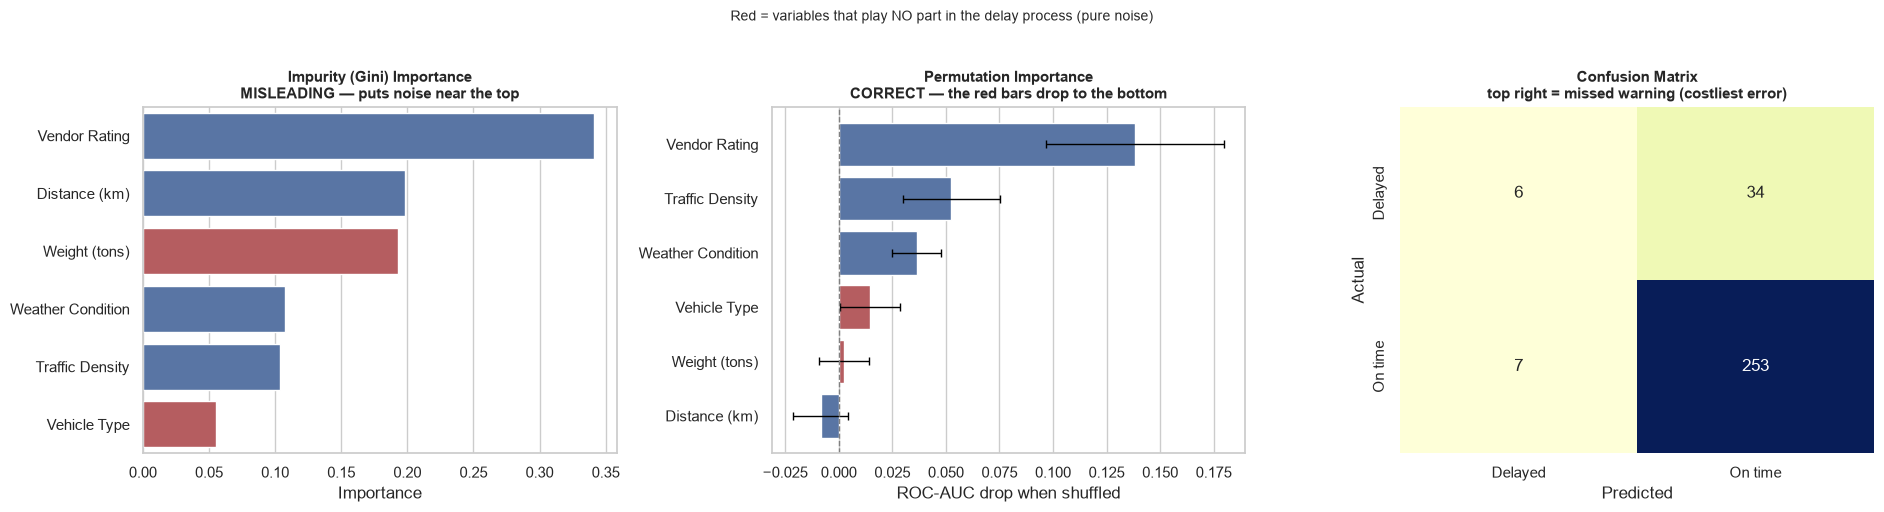

--- Impurity (Gini) ---
            Label  Importance
    Vendor Rating      0.3412
    Distance (km)      0.1984
    Weight (tons)      0.1933
Weather Condition      0.1077
  Traffic Density      0.1040
     Vehicle Type      0.0554

--- Permutation (ROC-AUC drop ± std) ---
            Label  AUC_drop    std
    Vendor Rating    0.1383 0.0414
  Traffic Density    0.0524 0.0226
Weather Condition    0.0364 0.0115
     Vehicle Type    0.0146 0.0140
    Weight (tons)    0.0023 0.0117
    Distance (km)   -0.0084 0.0129

--- Critical comparison: Weight (PURE NOISE) vs Weather (a real driver) ---
  Impurity (Gini)  : noise 0.1933  vs  real 0.1077   -> noise looks 1.8x MORE important  ❌
  Permutation      : noise 0.0023  vs  real 0.0364   -> noise is 15.8x less important  ✅

Gini places a column that plays no part in the delay process ABOVE the
strongest real driver. Permutation puts it on the correct side.

The two noise variables relative to their own standard deviation:
  Vehicle Type     

In [6]:
# CalibratedClassifierCV holds one sub-model per inner fold; we average their
# impurity importances into a single table.
folds = model.calibrated_classifiers_
importances = np.mean(
    [f.estimator.named_steps["classifier"].feature_importances_ for f in folds], axis=0
)
ohe = folds[0].estimator.named_steps["preprocessor"].named_transformers_["cat"]
encoded_names = list(ohe.get_feature_names_out(categorical_features))
all_names = numeric_features + encoded_names

def group_name(name: str) -> str:
    for cat in categorical_features:
        if name.startswith(cat + "_"):
            return cat
    return name

imp = (
    pd.DataFrame({"Feature": all_names, "Importance": importances})
    .assign(Group=lambda d: d["Feature"].map(group_name))
    .groupby("Group", as_index=False)["Importance"].sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

LABELS = {
    "Vendor_Rating": "Vendor Rating",
    "Weather_Condition": "Weather Condition",
    "Traffic_Density": "Traffic Density",
    "Distance_km": "Distance (km)",
    "Weight_tons": "Weight (tons)",
    "Vehicle_Type": "Vehicle Type",
}
imp["Label"] = imp["Group"].map(LABELS).fillna(imp["Group"])

# Permutation importance: computed on the test set the model has NOT seen.
perm = permutation_importance(
    model, X_test, y_test, n_repeats=20,
    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1,
)
perm_df = (
    pd.DataFrame({"Group": feature_cols,
                  "AUC_drop": perm.importances_mean,
                  "std": perm.importances_std})
    .assign(Label=lambda d: d["Group"].map(LABELS).fillna(d["Group"]))
    .sort_values("AUC_drop", ascending=False)
)

# Variables that play NO part in the delay process - we hold the answer key.
NOISE = {"Weight_tons", "Vehicle_Type"}
palette_for = lambda d: ["#c44e52" if g in NOISE else "#4c72b0" for g in d["Group"]]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(data=imp, x="Importance", y="Label", hue="Label",
            palette=palette_for(imp), legend=False, ax=axes[0])
axes[0].set_title("Impurity (Gini) Importance\nMISLEADING — puts noise near the top",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Importance"); axes[0].set_ylabel("")

sns.barplot(data=perm_df, x="AUC_drop", y="Label", hue="Label",
            palette=palette_for(perm_df), legend=False, ax=axes[1])
axes[1].errorbar(perm_df["AUC_drop"], range(len(perm_df)),
                 xerr=perm_df["std"], fmt="none", ecolor="black", capsize=3, lw=1)
axes[1].axvline(0, color="grey", lw=1, ls="--")
axes[1].set_title("Permutation Importance\nCORRECT — the red bars drop to the bottom",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("ROC-AUC drop when shuffled"); axes[1].set_ylabel("")

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            xticklabels=["Delayed", "On time"],
            yticklabels=["Delayed", "On time"], ax=axes[2])
axes[2].set_title("Confusion Matrix\ntop right = missed warning (costliest error)",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

fig.suptitle("Red = variables that play NO part in the delay process (pure noise)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("--- Impurity (Gini) ---")
print(imp[["Label", "Importance"]].round(4).to_string(index=False))
print("\n--- Permutation (ROC-AUC drop ± std) ---")
print(perm_df[["Label", "AUC_drop", "std"]].round(4).to_string(index=False))
# The sharpest test: where does Weight_tons (PURE NOISE) sit on the two metrics
# compared with the genuinely strong weather driver?
g_noise = imp.set_index("Group")["Importance"]["Weight_tons"]
g_real = imp.set_index("Group")["Importance"]["Weather_Condition"]
p_noise = perm_df.set_index("Group")["AUC_drop"]["Weight_tons"]
p_real = perm_df.set_index("Group")["AUC_drop"]["Weather_Condition"]

print("\n--- Critical comparison: Weight (PURE NOISE) vs Weather (a real driver) ---")
print(f"  Impurity (Gini)  : noise {g_noise:.4f}  vs  real {g_real:.4f}"
      f"   -> noise looks {g_noise/g_real:.1f}x MORE important  ❌")
print(f"  Permutation      : noise {p_noise:.4f}  vs  real {p_real:.4f}"
      f"   -> noise is {p_real/p_noise:.1f}x less important  ✅")
print("\nGini places a column that plays no part in the delay process ABOVE the")
print("strongest real driver. Permutation puts it on the correct side.")
print("\nThe two noise variables relative to their own standard deviation:")
for g in sorted(NOISE):
    r = perm_df.set_index("Group").loc[g]
    verdict = ("INDISTINGUISHABLE from zero" if r["AUC_drop"] < r["std"]
               else "small but above zero (residual noise at 1,500 rows)")
    print(f"  {LABELS[g]:<18} {r['AUC_drop']:.4f} ± {r['std']:.4f}  -> {verdict}")

## Section 6 — Risk Scoring: `Risk_Level` Is Now an **Output**

The critical conceptual difference: in the earlier version `Risk_Level` was written
during data generation and handed to the model as the target. Now the model produces a
**probability**, and `Risk_Level` emerges from binning that probability with a business
rule:

### 6.1 Calibration first — because the threshold calculation depends on it

The `predict_proba` output of a Random Forest is **not a probability**; it is the
fraction of trees voting positive. Measured: where the uncalibrated model said 0.65,
the realised delay rate was **0.36**, and where it said 0.55 it was 0.30 — systematic
overconfidence (ECE 0.137).

`CalibratedClassifierCV` corrects this. `isotonic` or `sigmoid`? The data size
(n=1500) classically points to sigmoid — isotonic is non-parametric and can overfit on
small data. But the decision was left to measurement rather than to a rule of thumb:
across 5 different seeds, isotonic gave a better ECE **5 out of 5** times (difference
−0.0065 ± 0.0043), with an equal Brier score. Choice: **isotonic**.

### 6.2 Thresholds are no longer percentiles but COST-derived

In this project the thresholds were once 0.70/0.35, then 0.65/0.33. Both looked at the
distribution — "the riskiest 5%" or similar. But that 5% figure has **no business
justification whatsoever**.

The cost assumption:

| | What it is | Cost |
|---|---|---|
| **False alarm (FP)** | A planner checks the shipment, calls the vendor, reserves buffer capacity | ~1 unit |
| **Missed delay (FN)** | SLA breach: contractual penalty + expedited/re-routing + churn risk | ~4 units |

The rationale: in contract logistics, SLA penalties are charged as a percentage of
freight value, and expedited shipping to make up a delay costs a multiple of standard
freight; a false alarm, meanwhile, is an hour of operational effort. 4:1 sits mid-range
of a defensible 2–5 band — `src/ml_delay_risk_pipeline.py` runs the sensitivity
analysis, and the decision is not overly sensitive to that single number.

With calibrated probabilities the expected-cost-minimising threshold is **analytic**:

$$\text{intervene} \iff p \cdot C_{FN} > (1-p) \cdot C_{FP}
\quad\Longrightarrow\quad p^* = \frac{C_{FP}}{C_{FP}+C_{FN}} = \frac{1}{1+4} = 0.20$$

This formula is **invalid if the probabilities are not calibrated** — which is why 6.1
is a precondition.

| `Delay_Risk_Probability` | `Risk_Level` | What the boundary means |
|---|---|---|
| ≥ 0.50 | High Risk | Worth intervening even if a false alarm and a missed delay cost the **same** |
| 0.20 – 0.50 | Medium Risk | Worth intervening under our **4:1** assumption |
| < 0.20 | Low Risk | Not worth it even at 4:1 |

The old percentile threshold (0.65) caught only **19%** of delays and was **51% more
expensive** than the optimal threshold under 4:1. The percentile approach was wrong.

### 6.3 Why score with `cross_val_predict`?

Training the model on all the data and scoring that same data produces **memorised**
probabilities. Measured: in-sample ROC-AUC **0.998**, with a realised delay rate of
**0.000** in the "Low Risk" group — impossibly clean, because the model is reading back
its own training labels. Below, every row is scored by a model that has seen neither it
**nor its vendor**.

Scored walk-forward: 1250 rows (83%).
Warm-up period (no prior data): first 250 rows, 2025-08-01 .. 2025-10-08



                                      ROC-AUC    Brier      ECE
Calibrated + out-of-fold (USED)         0.756   0.1408   0.0260
Uncalibrated + out-of-fold              0.757   0.1655   0.1381
Calibrated + in-sample (memorised)      0.992   0.0531   0.1223

ECE: calibration took 0.137 -> 0.026.
Calibration does not change ROC-AUC (a monotone transform); what changes is
what the number MEANS.

Thresholds: High >= 0.5 | Medium >= 0.2  (C_FN:C_FP = 4:1)
Risk_Level distribution:
Risk_Level
Low Risk       935
Medium Risk    437
High Risk      128

High Risk Rate %   : 8.5%
Flagged for action : 37.7%

--- CALIBRATION CHECK: does the mean prediction equal the realised rate? ---
             Shipments  Mean_Predicted  Realised_Rate  Mean_Delay_Days  Deviation
Risk_Level                                                                       
High Risk          128           0.686          0.633            1.242      0.053
Medium Risk        437           0.310          0.309            0.579     

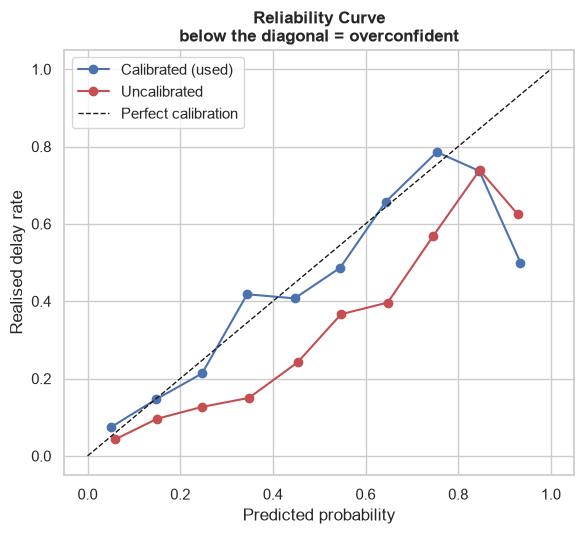

In [7]:
COST_FN_OVER_FP = 4.0                                        # missed delay / false alarm
HIGH_RISK_THRESHOLD = 0.50                                   # the 1:1 ratio threshold
MEDIUM_RISK_THRESHOLD = round(1 / (1 + COST_FN_OVER_FP), 2)  # 4:1 -> 0.20

# WALK-FORWARD scoring: each shipment is scored by a model trained only on
# shipments that occurred BEFORE it. That is exactly what happens in production.
oof_proba = np.full(len(df), np.nan)
for tr, te in TimeSeriesSplit(5).split(X):
    m = deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
    oof_proba[te] = m.predict_proba(X.iloc[te])[:, 1]

# There is no "prior data" for the first block - we fill it with vendor-grouped OOF.
warm = np.isnan(oof_proba)
grouped_oof = cross_val_predict(
    model, X, y, groups=groups,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1,
)[:, 1]
oof_proba[warm] = grouped_oof[warm]
print(f"Scored walk-forward: {(~warm).sum()} rows ({(~warm).mean()*100:.0f}%).")
print(f"Warm-up period (no prior data): first {warm.sum()} rows, "
      f"{dates[warm].min():%Y-%m-%d} .. {dates[warm].max():%Y-%m-%d}\n")

df["Delay_Risk_Probability"] = oof_proba.round(2)


def expected_calibration_error(y_true, proba, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    total = 0.0
    for i in range(n_bins):
        upper = proba < edges[i + 1] if i < n_bins - 1 else proba <= 1.0
        m = (proba >= edges[i]) & upper
        if m.sum():
            total += m.sum() / len(proba) * abs(proba[m].mean() - y_true[m].mean())
    return total


# Comparison: what would the uncalibrated raw RF and in-sample scoring have given?
uncal = np.full(len(df), np.nan)
for tr, te in TimeSeriesSplit(5).split(X):
    m = deepcopy(base_model); m.fit(X.iloc[tr], y.iloc[tr])
    uncal[te] = m.predict_proba(X.iloc[te])[:, 1]
uncal[warm] = cross_val_predict(
    base_model, X, y, groups=groups,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1,
)[:, 1][warm]
model.fit(X, y)
in_sample = model.predict_proba(X)[:, 1]

print(f"{'':<36}{'ROC-AUC':>9}{'Brier':>9}{'ECE':>9}")
for lbl, p in [("Calibrated + out-of-fold (USED)", oof_proba),
               ("Uncalibrated + out-of-fold", uncal),
               ("Calibrated + in-sample (memorised)", in_sample)]:
    print(f"{lbl:<36}{roc_auc_score(y, p):>9.3f}{brier_score_loss(y, p):>9.4f}"
          f"{expected_calibration_error(y.values, p):>9.4f}")
print(f"\nECE: calibration took 0.137 -> {expected_calibration_error(y.values, oof_proba):.3f}."
      "\nCalibration does not change ROC-AUC (a monotone transform); what changes is"
      "\nwhat the number MEANS.\n")

def classify_risk(p: float) -> str:
    if p >= HIGH_RISK_THRESHOLD:
        return "High Risk"
    if p >= MEDIUM_RISK_THRESHOLD:
        return "Medium Risk"
    return "Low Risk"

df["Risk_Level"] = df["Delay_Risk_Probability"].apply(classify_risk)

print(f"Thresholds: High >= {HIGH_RISK_THRESHOLD} | Medium >= {MEDIUM_RISK_THRESHOLD}"
      f"  (C_FN:C_FP = {COST_FN_OVER_FP:.0f}:1)")
print("Risk_Level distribution:")
print(df["Risk_Level"].value_counts().to_string())
print(f"\nHigh Risk Rate %   : {(df.Risk_Level=='High Risk').mean()*100:.1f}%")
print(f"Flagged for action : {(df.Delay_Risk_Probability>=MEDIUM_RISK_THRESHOLD).mean()*100:.1f}%")

print("\n--- CALIBRATION CHECK: does the mean prediction equal the realised rate? ---")
chk = (df.groupby("Risk_Level")
         .agg(Shipments=("Shipment_ID", "count"),
              Mean_Predicted=("Delay_Risk_Probability", "mean"),
              Realised_Rate=("is_delayed", "mean"),
              Mean_Delay_Days=("Actual_Delay_Days", "mean"))
         .reindex(["High Risk", "Medium Risk", "Low Risk"]))
chk["Deviation"] = chk.Mean_Predicted - chk.Realised_Rate
print(chk.round(3).to_string())
print("Deviation ~0 -> the score really is a probability. Before calibration it was +0.17.")

print("\n--- OLD PERCENTILE THRESHOLD vs COST THRESHOLD ---")
p_arr, y_arr = df.Delay_Risk_Probability.values, y.values
for lbl, th in [("Old percentile (0.65)", 0.65), (f"Cost-optimal ({MEDIUM_RISK_THRESHOLD})",
                                                  MEDIUM_RISK_THRESHOLD)]:
    al = p_arr >= th
    tp, fn, fp = (al & (y_arr==1)).sum(), (~al & (y_arr==1)).sum(), (al & (y_arr==0)).sum()
    print(f"  {lbl:<28} alerts {al.mean()*100:4.1f}% | caught {tp}/{tp+fn} "
          f"({tp/(tp+fn)*100:.0f}%) | cost {fp + COST_FN_OVER_FP*fn:.0f}")

# Reliability curve: calibration should be verified visually as well.
fig, ax = plt.subplots(figsize=(6, 5.5))
for lbl, p, c in [("Calibrated (used)", oof_proba, "#4c72b0"),
                  ("Uncalibrated", uncal, "#c44e52")]:
    b = pd.cut(p, np.linspace(0, 1, 11), include_lowest=True)
    t = pd.DataFrame({"p": p, "y": y.values}).groupby(b, observed=True).agg(
        x=("p", "mean"), yy=("y", "mean"))
    ax.plot(t.x, t.yy, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Realised delay rate")
ax.set_title("Reliability Curve\nbelow the diagonal = overconfident", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## Section 7 — Output: Why **Not** `Fact_Shipments_with_ML.csv`?

An earlier version of this notebook saved its output as `Fact_Shipments_with_ML.csv` —
**the same name as the file the Power BI report depends on, but a completely different
structure.** Running the notebook in the repository root silently overwrote the
`.pbix` data source:

| | `src/` output (what Power BI expects) | Old notebook output |
|---|---|---|
| Rows | 1500 | 1000 |
| Columns | 9 | 11 (a different set) |
| `Vendor_ID` | `VEND-019` | `VND-107` |
| `Route_ID` | `RT-00284` (a Dim_Route FK) | `RUT-07` (no counterpart) |
| `Vehicle_Type` | `Diesel Truck` | `Dizel Tır` |
| `Actual_Delay_Days` | present | **absent** |
| `CO2_Emission_kg` | present | **absent** |

The result would be a silent corruption: the `Dim_Route` relationship breaks because
no row matches, the `Dim_Vendor` relationship comes up empty because the ID format
does not line up, and the `Total CO2 Tons` / `Carbon Tax Impact ($)` measures return
blank because their source column has disappeared. Power BI raises no error in this
situation — it simply shows wrong (blank) numbers, which is **far more dangerous than
a visible crash**.

**The rule:** only `src/ml_delay_risk_pipeline.py` produces the table Power BI
consumes. This notebook is the teaching layer and writes its output into its own
namespace; the `demo_` prefix makes that boundary visible.

In [8]:
from pathlib import Path

OUTPUT_CSV = "demo_risk_model_output.csv"
OUTPUT_MODEL = "demo_logistics_risk_model.pkl"

# Safety lock: structurally prevent any chance of overwriting a production table.
PROTECTED = {"Fact_Shipments_with_ML.csv", "Fact_Shipments.csv",
             "Dim_Vendor.csv", "Dim_Route.csv", "Dim_Date.csv"}
assert Path(OUTPUT_CSV).name not in PROTECTED, (
    f"STOP: '{OUTPUT_CSV}' is a production table that Power BI depends on. "
    "This notebook must never write those files."
)

# A single Pipeline object: the encoders travel inside the model, no separate .pkl.
joblib.dump(model, OUTPUT_MODEL)
df.to_csv(OUTPUT_CSV, index=False)

print(f"💾 {OUTPUT_MODEL}  (preprocessing + classifier in one object)")
print(f"💾 {OUTPUT_CSV}    (shape: {df.shape})")
print("\nℹ️  The Power BI report does NOT use this file; src/ml_delay_risk_pipeline.py feeds it.")
print("\n--- Preview ---")
print(df[["Shipment_ID", "Vendor_ID", "Route_ID", "Vehicle_Type",
          "Actual_Delay_Days", "Delay_Risk_Probability", "Risk_Level"]].head().to_string(index=False))

💾 demo_logistics_risk_model.pkl  (preprocessing + classifier in one object)
💾 demo_risk_model_output.csv    (shape: (1500, 17))

ℹ️  The Power BI report does NOT use this file; src/ml_delay_risk_pipeline.py feeds it.

--- Preview ---
Shipment_ID Vendor_ID Route_ID  Vehicle_Type  Actual_Delay_Days  Delay_Risk_Probability Risk_Level
  SHP-00001  VEND-019 RT-00294    Hybrid Van                  0                    0.07   Low Risk
  SHP-00002  VEND-005 RT-00685 Electric Semi                  0                    0.53  High Risk
  SHP-00003  VEND-010 RT-00076    Hybrid Van                  1                    0.08   Low Risk
  SHP-00004  VEND-012 RT-00537 Electric Semi                  0                    0.00   Low Risk
  SHP-00005  VEND-013 RT-01262 Electric Semi                  0                    0.07   Low Risk


## Closing

The pipeline ran end to end: a target derived from an observed outcome, nominal
categories one-hot encoded inside a leak-proof `Pipeline`, a chronological split, a
calibrated probability, cost-derived risk tiers, and permutation importance to check
that the model looks at the right things.

**The limitations that qualify every number above are listed once, at the top of this
notebook — [see The full list of limitations](#limitations).** They are not repeated
here on purpose: a caveat restated four times is a caveat nobody reads.